### Motivation of the study.
This code uses preprocessed data to prepare scatter plots (see Fig. 1) of detrended monthly mean anomalies in the tropical middle stratosphere for the observations and the TOMCAT CTM simulation. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import sys
import seaborn as sns
from scipy.stats import linregress
sns.set_style("whitegrid", {"grid.color": ".6", "grid.linestyle": ":"})

sys.path.append('/path/to/the/helper_functions/')
from helper_functions import detrend_df, process_dataset, align_and_dropna_same_rows

In [ ]:
# Variables to analyze
start, end = "2004-01", "2021-12"
var_names_improved = ["w*", "N$_2$O", "NO$_2$", "O$_3$"]
data_sources = ["OBS" , "TOMCAT"]

base_in = "/path/to/the/files/created/with/1_data_preprocessing/notebook/"
files = {
    "TOMCAT": f"ctm741_data_collection_interpolated_{start[:4]}-{end[:4]}.nc",
    "OBS": f"obs_data_collection_interpolated_{start[:4]}-{end[:4]}.nc",
}

variable_mappings = {
    "TOMCAT": {
        "NO2_mm_anomaly": (r"NO$_2$", 1e9),
        "O3_mm_anomaly": (r"O$_3$", 1e6),
        "N2O_mm_anomaly": (r"N$_2$O", 1e9),
        "WSTAR_anomaly": (r"w*", 1000),
        "te_mm_anomaly": (r"T", 1),
    },
    "OBS": {
        "osiris_no2_anomaly": (r"NO$_2$", 1e9),
        "osiris_o3_anomaly": (r"O$_3$", 1e6),
        "mls_n2o_anomaly": (r"N$_2$O", 1e9),
        "era5_w_anomaly": (r"w*", 1000),
        "era5_ta_anomaly": (r"T", 1),
    },
}


df_dict = {}

for source in data_sources:
    df = process_dataset(base_in, files[source], variable_mappings[source])
    df = df[var_names_improved].sort_index()
    df_dict[source] = df

# -------------------- choose which sets must be same length --------------------
must_match_keys = ["OBS", "TOMCAT"]
df_dict, matched_keys, common_time_valid = align_and_dropna_same_rows(df_dict, must_match_keys)

print(
    f"Aligned & de-NaNed across: {matched_keys}\n"
    f"N={len(common_time_valid)}, {common_time_valid.min()} to {common_time_valid.max()}"
)

# Sanity checks
for k in matched_keys:
    print(k, len(df_dict[k]), df_dict[k].index.min(), df_dict[k].index.max())

assert all(df_dict[matched_keys[0]].index.equals(df_dict[k].index) for k in matched_keys[1:])


Aligned & de-NaNed across: ['OBS', 'TOMCAT']
N=199, 2004-08-01 00:00:00 to 2021-12-01 00:00:00
OBS 199 2004-08-01 00:00:00 2021-12-01 00:00:00
TOMCAT 199 2004-08-01 00:00:00 2021-12-01 00:00:00


In [3]:
full_range = pd.date_range(start='2004-01-01', end='2021-12-01', freq='MS')
missing_dates = full_range.difference(df_dict['OBS']['w*'].index)
print ('Missing dates')
print (missing_dates)

Missing dates
DatetimeIndex(['2004-01-01', '2004-02-01', '2004-03-01', '2004-04-01',
               '2004-05-01', '2004-06-01', '2004-07-01', '2017-10-01',
               '2018-06-01', '2018-07-01', '2018-12-01', '2019-05-01',
               '2019-06-01', '2020-05-01', '2020-06-01', '2020-07-01',
               '2021-06-01'],
              dtype='datetime64[ns]', freq=None)


In [4]:
detrend = True
if detrend: 
    df_obs = detrend_df (df_dict['OBS'].reset_index())
    df_ctm = detrend_df (df_dict['TOMCAT'].reset_index())

### Figure 1.

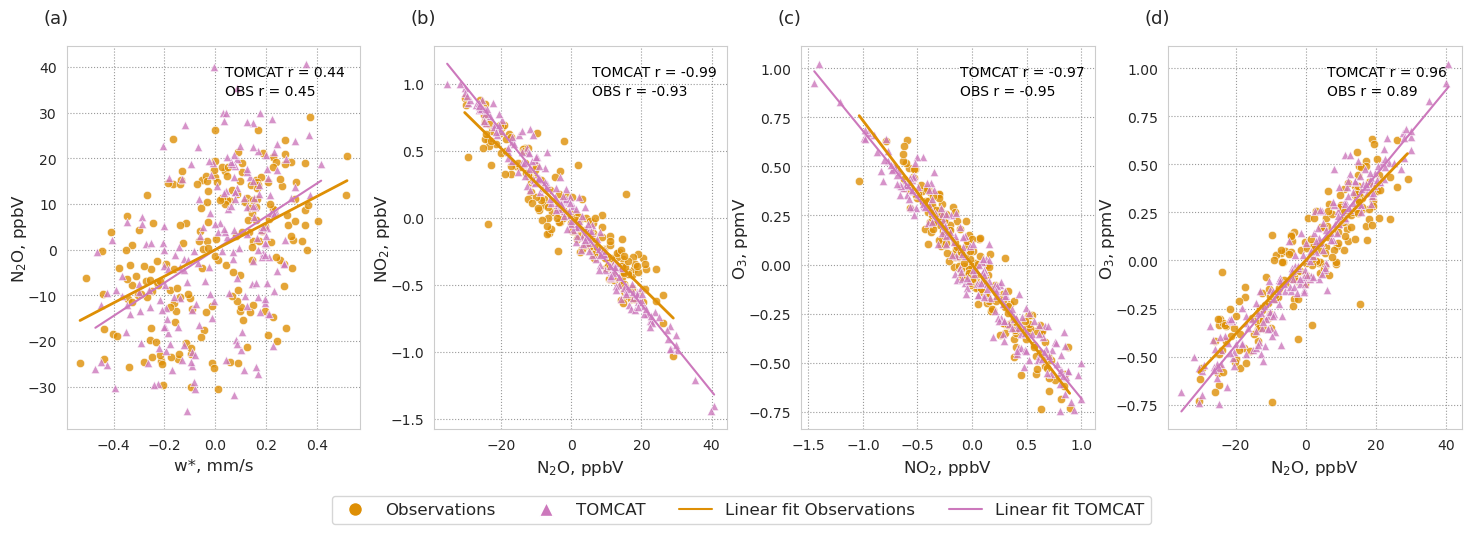

In [ ]:

# --- Pairs for panels a–d--
variable_pairs = [
    (r'w*',     r'N$_2$O'), # panel a
    (r'N$_2$O', r'NO$_2$'),
    (r'NO$_2$', r'O$_3$'),
    (r'N$_2$O', r'O$_3$')   # panel d
]
panel_labels = ['a', 'b', 'c', 'd']

colors = sns.color_palette("colorblind", 5)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), constrained_layout=False)

# Define markers/linestyles
obs_marker = 'o'
tomcat_marker = '^'
line_style = '-'

# Consistent colors 
obs_color = colors[1]
tomcat_color = colors[4]

# Store correlations 
obs_correlations = []
tomcat_correlations = []

for i, (ax, (var_x, var_y)) in enumerate(zip(axes, variable_pairs)):

    # Scatter plots
    sns.scatterplot(
        data=df_obs, x=var_x, y=var_y, ax=ax,
        marker=obs_marker, alpha=0.8, color=obs_color,
        label='Observations', legend=False
    )

    sns.scatterplot(
        data=df_ctm, x=var_x, y=var_y, ax=ax,
        marker=tomcat_marker, alpha=0.8, color=tomcat_color,
        label='TOMCAT', legend=False
    )

    # Regression + r for TOMCAT
    period_data_ctm = df_ctm.dropna(subset=[var_x, var_y])
    if len(period_data_ctm) >= 2:
        slope, intercept, r_value, _, _ = linregress(period_data_ctm[var_x], period_data_ctm[var_y])
        x_vals = np.linspace(period_data_ctm[var_x].min(), period_data_ctm[var_x].max(), 100)
        y_vals = intercept + slope * x_vals
        sns.lineplot(x=x_vals, y=y_vals, ax=ax, linestyle=line_style, color=tomcat_color)
        tomcat_correlations.append(r_value)
    else:
        tomcat_correlations.append(np.nan)

    # Regression + r for OBS
    period_data_obs = df_obs.dropna(subset=[var_x, var_y])
    if len(period_data_obs) >= 2:
        slope, intercept, r_value, _, _ = linregress(period_data_obs[var_x], period_data_obs[var_y])
        x_vals = np.linspace(period_data_obs[var_x].min(), period_data_obs[var_x].max(), 100)
        y_vals = intercept + slope * x_vals
        sns.lineplot(x=x_vals, y=y_vals, ax=ax, linestyle=line_style, linewidth=2, color=obs_color)
        obs_correlations.append(r_value)
    else:
        obs_correlations.append(np.nan)

    # Labels with units
    ax.set_xlabel(
        f'{var_x}, mm/s' if var_x == r'w*'
        else f'{var_x}, ppbV' if var_x in [r'N$_2$O', r'NO$_2$']
        else f'{var_x}, ppmV',
        fontsize=12
    )
    ax.set_ylabel(
        f'{var_y}, ppbV' if var_y in [r'N$_2$O', r'NO$_2$']
        else f'{var_y}, ppmV',
        fontsize=12,
        labelpad=-1
    )

    # r values text 
    r_ctm = tomcat_correlations[-1]
    r_obs = obs_correlations[-1]

    ax.text(
        0.54, 0.95,
        f'TOMCAT r = {r_ctm:.2f}' if np.isfinite(r_ctm) else 'TOMCAT r = NaN',
        transform=ax.transAxes,
        fontsize=10,
        va='top',
        color='k'
    )
    ax.text(
        0.54, 0.90,
        f'OBS r = {r_obs:.2f}' if np.isfinite(r_obs) else 'Observations r = NaN',
        transform=ax.transAxes,
        fontsize=10,
        va='top',
        color='k'
    )

    # Panel label (a/b/c/d)
    ax.text(
        -0.08, 1.05,
        f'({panel_labels[i]})',
        transform=ax.transAxes,
        fontsize=13,
        va='bottom',
        ha='left',
        clip_on=False
    )

    # Ensure no axis legend exists
    if ax.legend_ is not None:
        ax.legend_.remove()

# Single legend below subplots
handles = [
    plt.Line2D([0], [0], marker=obs_marker, linestyle='None',
               markersize=10, color='w', markerfacecolor=obs_color,
               label='Observations'),
    plt.Line2D([0], [0], marker=tomcat_marker, linestyle='None',
               markersize=10, color='w', markerfacecolor=tomcat_color,
               label='TOMCAT'),
    plt.Line2D([0], [0], linestyle=line_style,
               color=obs_color, label='Linear fit Observations'),
    plt.Line2D([0], [0], linestyle=line_style,
               color=tomcat_color, label='Linear fit TOMCAT'),
]

fig.legend(handles=handles, loc='upper center', fontsize=12,
           bbox_to_anchor=(0.5, -0.08), ncol=4)

# Layout so legend fits
plt.subplots_adjust(top=0.9, bottom=0.05, wspace=0.25, hspace=0.35)

plt.show()
# plt.savefig ('scatter_plots.pdf', bbox_inches = 'tight', dpi = 300)
